# EXP 001: Teórico x Experimental
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# --- CALCULAR O PARAMETRO DE ORDEM ---
def order_parameter(signal_matrix):
    analytic_signal = hilbert(signal_matrix, axis=0)
    phases = np.angle(analytic_signal)
    r_complex = np.mean(np.exp(1j * phases), axis=1)
    return np.abs(r_complex)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# --- PEGAR OS DADOS ADQUIRIDOS ---
files = ['exp001a.csv', 'exp001b.csv', 'exp001c.csv']
Rf_values = np.array([10000, 20000, 70000])  # Ohms
tempo_de_corte = 10.0 

r_means, r_stds = [], []

for file in files:
    data = pd.read_csv(file, header=None, names=['tempo', 'oscilador_1', 'oscilador_2'])
    data_estavel = data[data['tempo'] >= tempo_de_corte].reset_index(drop=True)
    signals = data_estavel[['oscilador_1', 'oscilador_2']].values
    r = order_parameter(signals)
    r_means.append(np.mean(r))
    r_stds.append(np.std(r))

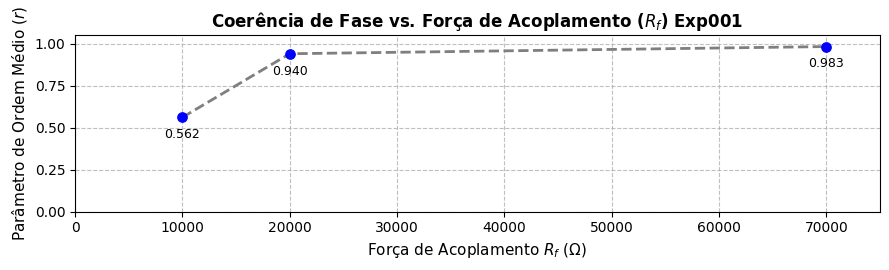

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# --- PLOTAR O GRÁFICO EXPERIMENTAL ---
plt.figure(figsize=(9,2.8))  # formato horizontal slim
plt.plot(Rf_values, r_means, linestyle='--', color='tab:gray', linewidth=2, label="Experimento")

# Pontos vermelhos nos valores de Rf + anotações
for i, (x, y) in enumerate(zip(Rf_values, r_means)):
    plt.scatter(x, y, color='blue', s=45, zorder=3)
    
    # Valor de Rf (abaixo do ponto)
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                 xytext=(0, -15), ha='center', fontsize=9, color='black')
    
plt.title("Coerência de Fase vs. Força de Acoplamento ($R_f$) Exp001", fontsize=12, weight='bold')
plt.xlabel("Força de Acoplamento $R_f$ ($\\Omega$)", fontsize=11)
plt.ylabel('Parâmetro de Ordem Médio ($r$)', fontsize=11)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, 0.25)) 
plt.xlim(0, max(Rf_values) + 5000)
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

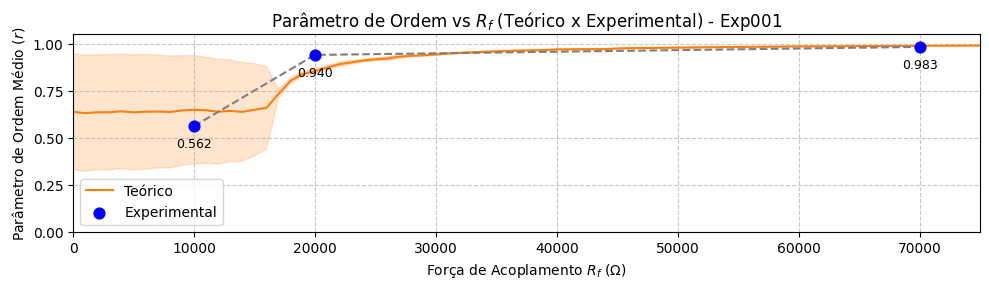

In [1]:
import numpy as np, scipy as sp, matplotlib.pyplot as plt, os
import pandas as pd
from scipy.signal import hilbert
import quadratureNetwork as qnet  # biblioteca dos osciladores

# --- DADOS TEÓRICOS ---
folderName = 'exp001'
allFiles = os.listdir(folderName)

Rf = []
pcMean = []
pcStd = []

for file in allFiles:
    if file[-3:] == 'mat':
        npzfile = sp.io.loadmat(folderName+'\\'+file)
        Rf.append(npzfile['Rf'][0,0])
        pcMean.append(npzfile['pcMean'][0,0])
        pcStd.append(npzfile['pcStd'][0,0])

Rf = np.array(Rf)
pcMean = np.array(pcMean)
pcStd = np.array(pcStd)
sorIdx = np.argsort(Rf)
Rf, pcMean, pcStd = Rf[sorIdx], pcMean[sorIdx], pcStd[sorIdx]

# --- DADOS EXPERIMENTAIS ---
def order_parameter(signal_matrix):
    analytic_signal = hilbert(signal_matrix, axis=0)
    phases = np.angle(analytic_signal)
    r_complex = np.mean(np.exp(1j * phases), axis=1)
    return np.abs(r_complex)

files = ['exp001a.csv', 'exp001b.csv', 'exp001c.csv']
Rf_values = np.array([10000, 20000, 70000])  # em Ohms
tempo_de_corte = 10.0

r_means, r_stds = [], []

for file in files:
    data = pd.read_csv(file, header=None, names=['tempo', 'oscilador_1', 'oscilador_2'])
    data_estavel = data[data['tempo'] >= tempo_de_corte].reset_index(drop=True)
    signals = data_estavel[['oscilador_1', 'oscilador_2']].values
    r = order_parameter(signals)
    r_means.append(np.mean(r))
    r_stds.append(np.std(r))

# --- PLOTAGEM UNIFICADA ---
plt.figure(figsize=(10,3))
plt.title(r'Parâmetro de Ordem vs $R_f$ (Teórico x Experimental) - Exp001')

# Teórico
plt.plot(Rf, pcMean, '-', color='tab:orange', label='Teórico')
plt.fill_between(Rf, pcMean-pcStd, pcMean+pcStd, color='tab:orange', alpha=0.2)

# Experimental
plt.scatter(Rf_values, r_means, color='blue', s=60, zorder=3, label="Experimental")
plt.plot(Rf_values, r_means, linestyle='--', color='tab:gray', linewidth=1.5)

# Marcação de pontos experimentais com valores
for x, y in zip(Rf_values, r_means):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                 xytext=(0, -15), ha='center', fontsize=9, color='black')

plt.xlabel(r"Força de Acoplamento $R_f$ ($\Omega$)")
plt.ylabel("Parâmetro de Ordem Médio ($r$)")
plt.xlim(0, max(Rf_values) + 5000)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.25, 0.25))  # igual ao modelo do exp002
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
